### [GitHub](https://github.com/msultanmahmud/Stress_WESAD/blob/master/Multiclass_Pipeline_Individual_sub_INTEC.ipynb)

In [2]:
# ! pip list

In [3]:
# ! pip install lightgbm

In [4]:
import numpy as np
import pandas as pd
import os
import sys
import random
import warnings
warnings.filterwarnings('ignore')
import pickle
from sklearn.model_selection import train_test_split
from sklearn import svm, metrics,preprocessing
#from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay,roc_curve, auc,classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_predict
from matplotlib import pyplot as plt
from collections import Counter
from scipy.stats import norm
import seaborn as sns; sns.set(font_scale=1.2)
%matplotlib inline
import time
import xgboost as xgb
import lightgbm as lgb

#### Redaing file

In [6]:
df=pd.read_csv('../dreamt_preprocessed.csv')
df.subject.nunique()

100

In [7]:
# Identify columns to drop if they exist
columns_to_drop = [col for col in df.columns if 'skewness' in col.lower() or 'kurtosis' in col.lower()]

# Drop only those columns that actually exist
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
df.head(5) 

,subject,epoch,label,C4-M1_min,C4-M1_max,C4-M1_mean,C4-M1_std,C4-M1_p5,C4-M1_p25,C4-M1_p50,...,HR_p95,IBI_min,IBI_max,IBI_mean,IBI_std,IBI_p5,IBI_p25,IBI_p50,IBI_p75,IBI_p95
0,S002,1,3.0,-0.000008,0.000008,6.380306e-09,0.000002,-0.000004,-1.318379e-06,4.882887e-08,...,72.85,1.0625,1.0625,1.0625,0.0,1.0625,1.0625,1.0625,1.0625,1.0625
1,S002,2,3.0,-0.000006,0.000005,4.531319e-08,0.000002,-0.000003,-1.123064e-06,-4.882887e-08,...,72.85,1.0625,1.0625,1.0625,0.0,1.0625,1.0625,1.0625,1.0625,1.0625
2,S002,3,3.0,-0.000004,0.000005,4.547595e-08,0.000002,-0.000002,-9.277485e-07,4.882887e-08,...,72.85,1.0625,1.0625,1.0625,0.0,1.0625,1.0625,1.0625,1.0625,1.0625
3,S002,4,3.0,-0.000017,0.000019,6.071056e-08,0.000003,-0.000004,-1.220722e-06,1.464866e-07,...,72.85,1.0625,1.0625,1.0625,0.0,1.0625,1.0625,1.0625,1.0625,1.0625
4,S002,5,3.0,-0.000008,0.000009,6.067801e-08,0.000002,-0.000004,-1.416037e-06,4.882887e-08,...,72.85,1.0625,1.0625,1.0625,0.0,1.0625,1.0625,1.0625,1.0625,1.0625


### Drop subject those who have some data Msisning 

In [9]:
df = df[~df['subject'].isin(['S062', 'S097'])]
pre_procss_all=df.copy()
pre_procss_all

,subject,epoch,label,C4-M1_min,C4-M1_max,C4-M1_mean,C4-M1_std,C4-M1_p5,C4-M1_p25,C4-M1_p50,...,HR_p95,IBI_min,IBI_max,IBI_mean,IBI_std,IBI_p5,IBI_p25,IBI_p50,IBI_p75,IBI_p95
0,S002,1,3.0,-0.000008,0.000008,6.380306e-09,0.000002,-0.000004,-1.318379e-06,4.882887e-08,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
1,S002,2,3.0,-0.000006,0.000005,4.531319e-08,0.000002,-0.000003,-1.123064e-06,-4.882887e-08,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
2,S002,3,3.0,-0.000004,0.000005,4.547595e-08,0.000002,-0.000002,-9.277485e-07,4.882887e-08,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
3,S002,4,3.0,-0.000017,0.000019,6.071056e-08,0.000003,-0.000004,-1.220722e-06,1.464866e-07,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
4,S002,5,3.0,-0.000008,0.000009,6.067801e-08,0.000002,-0.000004,-1.416037e-06,4.882887e-08,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95142,S103,899,1.0,-0.000025,0.000045,2.679077e-08,0.000008,-0.000012,-4.638743e-06,-1.464866e-07,...,72.12,0.859375,0.906250,0.884599,0.016580,0.859375,0.859375,0.890625,0.890625,0.906250
95143,S103,900,1.0,-0.000035,0.000032,1.027685e-07,0.000008,-0.000014,-4.638743e-06,1.464866e-07,...,68.87,0.812500,0.890625,0.869016,0.019533,0.828125,0.859375,0.859375,0.890625,0.890625
95144,S103,901,1.0,-0.000083,0.000080,1.070654e-07,0.000011,-0.000013,-4.541085e-06,3.906310e-07,...,69.03,0.843750,0.906250,0.871021,0.019181,0.843750,0.859375,0.875000,0.875000,0.906250
95145,S103,902,1.0,-0.000049,0.000056,8.274866e-08,0.000009,-0.000013,-4.931716e-06,1.464866e-07,...,69.42,0.734375,0.937500,0.869594,0.061489,0.734375,0.875000,0.890625,0.906250,0.921875


In [10]:
## >>>>>> PPG DATA Separation done <<<<<<<<<<<<

In [11]:
wanted_keywords = ['BVP', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR', 'IBI']
pattern = '|'.join(wanted_keywords)
 
# Select columns that do NOT match the regex pattern
df_psg = pre_procss_all.loc[:, ~pre_procss_all.columns.str.contains(pattern, case=False, regex=True)]
df_psg
# Drop columns with any null (NaN) values
df_psg_cleaned = df_psg.dropna(axis=1, how='any')
# Optionally: print removed columns
psg_removed_cols = df_psg.columns[df_psg.isnull().any()].tolist()
print("Removed columns with nulls:", psg_removed_cols)
df_psg_cleaned
 
df_psg_cleaned = df_psg_cleaned[df_psg_cleaned['label'].isin([0,1,2])]
df_psg_cleaned.head(3)

Removed columns with nulls: []


,subject,epoch,label,C4-M1_min,C4-M1_max,C4-M1_mean,C4-M1_std,C4-M1_p5,C4-M1_p25,C4-M1_p50,...,RAT_p95,SAO2_min,SAO2_max,SAO2_mean,SAO2_std,SAO2_p5,SAO2_p25,SAO2_p50,SAO2_p75,SAO2_p95
305,S002,307,0.0,-0.000043,0.000020,-2.770550e-07,0.000007,-0.000010,-0.000003,4.394598e-07,...,0.000007,0.969907,0.969941,0.969924,0.000006,0.969915,0.969919,0.969924,0.969930,0.969934
306,S002,308,0.0,-0.000018,0.000014,6.477963e-09,0.000005,-0.000007,-0.000003,4.882887e-08,...,0.000005,0.958276,0.971334,0.966985,0.004638,0.959652,0.959699,0.969916,0.969931,0.969956
307,S002,309,0.0,-0.000050,0.000046,2.981816e-08,0.000008,-0.000011,-0.000003,2.441444e-07,...,0.000006,0.969916,0.969933,0.969924,0.000004,0.969918,0.969920,0.969924,0.969929,0.969931


In [12]:
### How many subjec
sample=df_psg_cleaned.subject.unique()[:15]
# # Sample the data (if needed)
df_sample = df_psg_cleaned[df_psg_cleaned.subject.isin(sample)]
df_sample.head()
# df=df_psg_cleaned.copy()

,subject,epoch,label,C4-M1_min,C4-M1_max,C4-M1_mean,C4-M1_std,C4-M1_p5,C4-M1_p25,C4-M1_p50,...,RAT_p95,SAO2_min,SAO2_max,SAO2_mean,SAO2_std,SAO2_p5,SAO2_p25,SAO2_p50,SAO2_p75,SAO2_p95
305,S002,307,0.0,-0.000043,0.000020,-2.770550e-07,0.000007,-0.000010,-0.000003,4.394598e-07,...,0.000007,0.969907,0.969941,0.969924,0.000006,0.969915,0.969919,0.969924,0.969930,0.969934
306,S002,308,0.0,-0.000018,0.000014,6.477963e-09,0.000005,-0.000007,-0.000003,4.882887e-08,...,0.000005,0.958276,0.971334,0.966985,0.004638,0.959652,0.959699,0.969916,0.969931,0.969956
307,S002,309,0.0,-0.000050,0.000046,2.981816e-08,0.000008,-0.000011,-0.000003,2.441444e-07,...,0.000006,0.969916,0.969933,0.969924,0.000004,0.969918,0.969920,0.969924,0.969929,0.969931
308,S002,310,0.0,-0.000018,0.000017,1.591821e-08,0.000005,-0.000008,-0.000003,4.882887e-08,...,0.000005,0.969920,0.969929,0.969924,0.000003,0.969920,0.969922,0.969924,0.969927,0.969929
309,S002,311,0.0,-0.000052,0.000067,1.513695e-07,0.000010,-0.000017,-0.000003,4.394598e-07,...,0.000010,0.969921,0.969928,0.969924,0.000001,0.969922,0.969924,0.969924,0.969925,0.969927


In [13]:
# df1=df_fusion_cleaned.copy()
# df1.head(3)

## Reading the stability score pickle that was save during the satability selection analysis

In [15]:
# with open("results_ss_v1.pkl", "rb") as f:
with open("stability_score_alpha_psg_v1.pkl", "rb") as f:
    results = pickle.load(f)
results.keys()

dict_keys([0.001, 0.01, 0.02, 0.04, 0.05, 0.07])

In [16]:
# # Define the keys you want to keep
# keep_alphas = [0.001, 0.01, 0.02, 0.04, 0.05, 0.07]

# # Filter the dictionary
# results_filtered = {k: v for k, v in results.items() if k in keep_alphas}
# results_filtered
# import pickle
# with open("stability_score_alpha_whole_v1.pkl", "wb") as f:
#     pickle.dump(results_filtered, f)


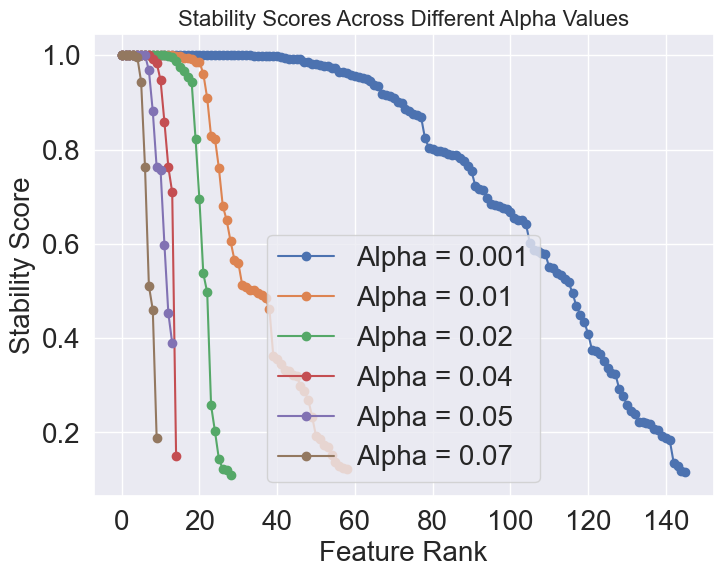

In [17]:
# Plot stability scores for each alpha
fs=20
plt.figure(figsize=(8, 6))

for alpha, df_alpha in results.items():
    filtered_df = df_alpha[df_alpha['Stability_Score'] >= 0.1]
    plt.plot(range(len(filtered_df)), filtered_df['Stability_Score'], label=f'Alpha = {alpha}', marker='o')

plt.title('Stability Scores Across Different Alpha Values',fontsize=16)
plt.xlabel('Feature Rank',fontsize=fs)
plt.ylabel('Stability Score',fontsize=fs)
plt.xticks(fontsize=fs)  # Make x-axis tick labels larger
plt.yticks(fontsize=fs)  # Make y-axis tick labels larger
plt.legend(fontsize=fs,loc='lower center')
plt.grid(True)
plt.show()

In [18]:
feature_importance_df_07=results[0.07][results[0.07].Stability_Score>=0.7]['Feature'].values
sel_col=np.append(feature_importance_df_07,'label')
### Selected features only
df1=df_sample[sel_col]
df1.head(3)

,ECG_min,ABDOMEN_min,CHIN_p25,RAT_max,FP1-O2_std,LAT_min,RAT_min,label
305,-0.000207,-0.000471,-0.000004,0.000047,0.000018,-0.000070,-0.000046,0.0
306,-0.000223,-0.000599,-0.000004,0.000012,0.000010,-0.000010,-0.000028,0.0
307,-0.000250,-0.000575,-0.000004,0.000019,0.000014,-0.000011,-0.000026,0.0


In [19]:
#   df_sample.subject.nunique()

### Classification based on the selected Features

In [21]:
# !jupyter kernelspec list

In [22]:
### Hyperopt

In [23]:
# from joblib import Parallel, delayed
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import make_pipeline
# import xgboost as xgb
# import lightgbm as lgb
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier
# from sklearn import svm
# import pandas as pd
# import numpy as np

# def preprocess_scaling(df):
#     '''Scales features and splits into train/test.'''
#     X = df.drop(columns=['label'])
#     y = df['label']
#     X_scaled = preprocessing.scale(X)
#     return train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# def train_and_evaluate(model, X_train, y_train, X_test, y_test, model_name, auc_mode='ovr'):
#     try:
#         model.fit(X_train, y_train)
#         y_pred = model.predict(X_test)

#         acc = accuracy_score(y_test, y_pred)
#         precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
#         recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
#         f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

#         # AUC calculation — multi-class
#         if hasattr(model, "predict_proba"):
#             y_probs = model.predict_proba(X_test)
#             auc = roc_auc_score(y_test, y_probs, multi_class=auc_mode, average='macro')
#         else:
#             auc = None  # SVM without probability=True will not support this

#         return (model_name, acc, f1, precision, recall, auc)
#     except Exception as e:
#         print(f"Error with model {model_name}: {e}")
#         return (model_name, None, None, None, None, None)

In [24]:
# from joblib import Parallel, delayed
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import make_pipeline
# import xgboost as xgb
# import lightgbm as lgb
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier
# from sklearn import svm
# import pandas as pd
# import numpy as np

# def preprocess_scaling(df):
#     '''Scales features and splits into train/test.'''
#     X = df.drop(columns=['label'])
#     y = df['label']
#     X_scaled = preprocessing.scale(X)
#     return train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# def train_and_evaluate(model, X_train, y_train, X_test, y_test, model_name, auc_mode='ovr'):
#     try:
#         model.fit(X_train, y_train)
#         y_pred = model.predict(X_test)

#         acc = accuracy_score(y_test, y_pred)
#         precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
#         recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
#         f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

#         # AUC calculation — multi-class
#         if hasattr(model, "predict_proba"):
#             y_probs = model.predict_proba(X_test)
#             auc = roc_auc_score(y_test, y_probs, multi_class=auc_mode, average='macro')
#         else:
#             auc = None  # SVM without probability=True will not support this

#         return (model_name, acc, f1, precision, recall, auc)
#     except Exception as e:
#         print(f"Error with model {model_name}: {e}")
#         return (model_name, None, None, None, None, None)

# from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
# from sklearn.model_selection import cross_val_score, train_test_split
# from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
# from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import StandardScaler
# import numpy as np
# import pandas as pd
# import xgboost as xgb
# import lightgbm as lgb
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn import svm
# import warnings
# warnings.filterwarnings('ignore')

# def optimize_model(model_name, X, y, auc_mode='ovr', max_evals=25):

#     def objective(params):
#         if model_name == 'KNN':
#             params['n_neighbors'] = range(1, 11)[params['n_neighbors']]
#             params['weights'] = ['uniform', 'distance'][params['weights']]
#             params['p'] = [1, 2][params['p']]
#             model = KNeighborsClassifier(**params)

#         elif model_name == 'DT':
#             params['criterion'] = ['gini', 'entropy'][params['criterion']]
#             model = DecisionTreeClassifier(**params)

#         elif model_name == 'XGBoost':
#             params['max_depth'] = int(params['max_depth'])
#             params['n_estimators'] = [100, 200][params['n_estimators']]
#             model = xgb.XGBClassifier(objective='multi:softprob', num_class=len(np.unique(y)),
#                                       eval_metric='mlogloss', use_label_encoder=False, **params)

#         elif model_name == 'LightGBM':
#             params['max_depth'] = int(params['max_depth'])
#             params['n_estimators'] = [100, 200][params['n_estimators']]
#             model = lgb.LGBMClassifier(**params)

#         elif model_name == 'RF':
#             params['max_depth'] = int(params['max_depth'])
#             params['n_estimators'] = [100, 200][params['n_estimators']]
#             params['max_features'] = ['auto', 'sqrt', 'log2'][params['max_features']]
#             model = RandomForestClassifier(**params)

#         elif model_name == 'SVM':
#             params['kernel'] = ['linear', 'rbf'][params['kernel']]
#             model = svm.SVC(probability=True, **params)

#         score = cross_val_score(model, X, y, scoring='accuracy', cv=3).mean()
#         return {'loss': -score, 'status': STATUS_OK}

#     # Define search spaces
#     spaces = {
#         'KNN': {
#             'n_neighbors': hp.choice('n_neighbors', list(range(1, 11))),
#             'weights': hp.choice('weights', ['uniform', 'distance']),
#             'p': hp.choice('p', [1, 2]),
#         },
#         'DT': {
#             'criterion': hp.choice('criterion', ['gini', 'entropy']),
#             'max_depth': hp.quniform('max_depth', 5, 50, 1),
#         },
#         'XGBoost': {
#             'max_depth': hp.quniform('max_depth', 3, 15, 1),
#             'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
#             'gamma': hp.uniform('gamma', 0, 0.5),
#             'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1),
#             'min_child_weight': hp.quniform('min_child_weight', 1, 6, 1),
#             'n_estimators': hp.choice('n_estimators', [100, 200]),
#         },
#         'LightGBM': {
#             'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
#             'max_depth': hp.quniform('max_depth', 10, 100, 1),
#             'min_child_weight': hp.uniform('min_child_weight', 0.1, 1),
#             'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1),
#             'n_estimators': hp.choice('n_estimators', [100, 200]),
#         },
#         'RF': {
#             'n_estimators': hp.choice('n_estimators', [100, 200]),
#             'max_depth': hp.quniform('max_depth', 10, 100, 1),
#             'max_features': hp.choice('max_features', ['auto', 'sqrt', 'log2']),
#         },
#         'SVM': {
#             'C': hp.loguniform('C', np.log(1e-3), np.log(100)),
#             'kernel': hp.choice('kernel', ['linear', 'rbf']),
#             'gamma': hp.uniform('gamma', 0.001, 0.1),
#         },
#     }

#     trials = Trials()
#     best = fmin(fn=objective,
#                 space=spaces[model_name],
#                 algo=tpe.suggest,
#                 max_evals=max_evals,
#                 trials=trials,
#                 rstate=np.random.default_rng(42))

#     # Reconstruct best model with mapped values
#     if model_name == 'KNN':
#         best['n_neighbors'] = range(1, 11)[best['n_neighbors']]
#         best['weights'] = ['uniform', 'distance'][best['weights']]
#         best['p'] = [1, 2][best['p']]
#         model = KNeighborsClassifier(**best)

#     elif model_name == 'DT':
#         best['criterion'] = ['gini', 'entropy'][best['criterion']]
#         best['max_depth'] = int(best['max_depth'])
#         model = DecisionTreeClassifier(**best)

#     elif model_name == 'XGBoost':
#         best['max_depth'] = int(best['max_depth'])
#         best['n_estimators'] = [100, 200][best['n_estimators']]
#         model = xgb.XGBClassifier(objective='multi:softprob', num_class=len(np.unique(y)),
#                                   eval_metric='mlogloss', use_label_encoder=False, **best)

#     elif model_name == 'LightGBM':
#         best['max_depth'] = int(best['max_depth'])
#         best['n_estimators'] = [100, 200][best['n_estimators']]
#         model = lgb.LGBMClassifier(**best)

#     elif model_name == 'RF':
#         best['max_depth'] = int(best['max_depth'])
#         best['n_estimators'] = [100, 200][best['n_estimators']]
#         best['max_features'] = ['auto', 'sqrt', 'log2'][best['max_features']]
#         model = RandomForestClassifier(**best)

#     elif model_name == 'SVM':
#         best['kernel'] = ['linear', 'rbf'][best['kernel']]
#         model = svm.SVC(probability=True, **best)

#     return model


# def multiple_model(df, auc_mode='ovr', max_evals=25):
#     X_train, X_test, y_train, y_test = preprocess_scaling(df)
#     model_name_list = ['KNN', 'DT', 'XGBoost', 'LightGBM', 'RF', 'SVM']
#     results = []

#     for name in model_name_list:
#         print(f"🔍 Tuning {name} ...")
#         model = optimize_model(name, X_train, y_train, auc_mode=auc_mode, max_evals=max_evals)
#         model.fit(X_train, y_train)
#         y_pred = model.predict(X_test)
#         y_prob = model.predict_proba(X_test)

#         auc = roc_auc_score(y_test, y_prob, multi_class=auc_mode, average='macro')
#         acc = accuracy_score(y_test, y_pred)
#         f1 = f1_score(y_test, y_pred, average='macro')
#         precision = precision_score(y_test, y_pred, average='macro')
#         recall = recall_score(y_test, y_pred, average='macro')

#         results.append([name, acc, auc, precision, recall, f1])

#     results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'AUC', 'Precision', 'Recall', 'F1'])
#     results_df.set_index('Model', inplace=True)
#     return results_df


### Ensemble Learning

In [26]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm
import xgboost as xgb
import lightgbm as lgb
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

def preprocess_scaling(df):
    '''Scales features and splits into train/test.'''
    X = df.drop(columns=['label'])
    y = df['label']
    X_scaled = preprocessing.scale(X)
    return train_test_split(X_scaled, y, test_size=0.2, random_state=42)

def train_and_evaluate(model, X_train, y_train, X_test, y_test, model_name, auc_mode='ovr'):
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

        # AUC calculation — multi-class
        if hasattr(model, "predict_proba"):
            y_probs = model.predict_proba(X_test)
            auc = roc_auc_score(y_test, y_probs, multi_class=auc_mode, average='macro')
        else:
            auc = None  # SVM without probability=True will not support this

        return (model_name, acc, f1, precision, recall, auc)
    except Exception as e:
        print(f"Error with model {model_name}: {e}")
        return (model_name, None, None, None, None, None)

# ------ Optimize a single model with Hyperopt ------
def optimize_model(model_name, X, y, auc_mode='ovr', max_evals=25):
    
    def objective(params):
        # Cast integer-valued hyperparameters
        if 'max_depth' in params:
            params['max_depth'] = int(params['max_depth'])
        if 'n_neighbors' in params:
            params['n_neighbors'] = int(params['n_neighbors'])
        if 'n_estimators' in params:
            params['n_estimators'] = int(params['n_estimators'])

        # Build model with params
        if model_name == 'KNN':
            model = KNeighborsClassifier(**params)
        elif model_name == 'DT':
            model = DecisionTreeClassifier(**params)
        elif model_name == 'XGBoost':
            model = xgb.XGBClassifier(objective='multi:softprob',
                                      num_class=len(np.unique(y)),
                                      eval_metric='mlogloss',
                                      use_label_encoder=False,
                                      **params)
        elif model_name == 'LightGBM':
            model = lgb.LGBMClassifier(**params)
        elif model_name == 'RF':
            model = RandomForestClassifier(**params)
        elif model_name == 'SVM':
            model = svm.SVC(probability=True, **params)

        score = cross_val_score(model, X, y, scoring='accuracy', cv=3).mean()
        return {'loss': -score, 'status': STATUS_OK}

    # --- Define search space ---
    spaces = {
        'KNN': {
            'n_neighbors': hp.quniform('n_neighbors', 1, 10, 1),
            'weights': hp.choice('weights', ['uniform', 'distance']),
            'p': hp.choice('p', [1, 2]),
        },
        'DT': {
            'criterion': hp.choice('criterion', ['gini', 'entropy']),
            'max_depth': hp.quniform('max_depth', 5, 50, 1),
        },
        'XGBoost': {
            'max_depth': hp.quniform('max_depth', 3, 15, 1),
            'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
            'gamma': hp.uniform('gamma', 0, 0.5),
            'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1),
            'min_child_weight': hp.quniform('min_child_weight', 1, 6, 1),
            'n_estimators': hp.quniform('n_estimators', 100, 200, 1),
        },
        'LightGBM': {
            'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
            'max_depth': hp.quniform('max_depth', 10, 100, 1),
            'min_child_weight': hp.uniform('min_child_weight', 0.1, 1),
            'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1),
            'n_estimators': hp.quniform('n_estimators', 100, 200, 1),
        },
        'RF': {
            'n_estimators': hp.quniform('n_estimators', 100, 200, 1),
            'max_depth': hp.quniform('max_depth', 10, 100, 1),
            'max_features': hp.choice('max_features', ['auto', 'sqrt', 'log2']),
        },
        'SVM': {
            'C': hp.loguniform('C', np.log(1e-3), np.log(100)),
            'kernel': hp.choice('kernel', ['linear', 'rbf']),
            'gamma': hp.uniform('gamma', 0.001, 0.1),
        },
    }

    trials = Trials()
    best = fmin(
        fn=objective,
        space=spaces[model_name],
        algo=tpe.suggest,
        max_evals=max_evals,
        trials=trials,
        rstate=np.random.default_rng(42)
    )

    # Recast int fields again before model instantiation
    for key in ['max_depth', 'n_neighbors', 'n_estimators']:
        if key in best:
            best[key] = int(best[key])

    if model_name == 'KNN':
        model = KNeighborsClassifier(**best)
    elif model_name == 'DT':
        model = DecisionTreeClassifier(**best)
    elif model_name == 'XGBoost':
        model = xgb.XGBClassifier(objective='multi:softprob',
                                  num_class=len(np.unique(y)),
                                  eval_metric='mlogloss',
                                  use_label_encoder=False,
                                  **best)
    elif model_name == 'LightGBM':
        model = lgb.LGBMClassifier(**best)
    elif model_name == 'RF':
        best['max_features'] = ['auto', 'sqrt', 'log2'][best['max_features']]
        model = RandomForestClassifier(**best)
    elif model_name == 'SVM':
        best['kernel'] = ['linear', 'rbf'][best['kernel']]
        model = svm.SVC(probability=True, **best)

    return model


# ------ Main function ------
def multiple_model(df, auc_mode='ovr', max_evals=25):
    # --- Preprocess ---
    print("✅ Columns:", df.columns.tolist())
    print("✅ Shape:", df.shape)
    print("✅ Unique labels:", df['label'].unique())

    X = df.drop(columns=['label'])
    y = df['label']

    if X.shape[1] == 0:
        raise ValueError("❌ No features were selected!")

    X = StandardScaler().fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

    model_name_list = ['KNN', 'DT', 'XGBoost', 'LightGBM', 'RF', 'SVM']
    results = []

    for name in model_name_list:
        print(f"🔍 Tuning {name} ...")
        model = optimize_model(name, X_train, y_train, auc_mode=auc_mode, max_evals=max_evals)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)

        auc = roc_auc_score(y_test, y_prob, multi_class=auc_mode, average='macro')
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        precision = precision_score(y_test, y_pred, average='macro')
        recall = recall_score(y_test, y_pred, average='macro')

        results.append([name, acc, auc, precision, recall, f1])

    # --- Compile Results ---
    results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'AUC', 'Precision', 'Recall', 'F1'])
    results_df.set_index('Model', inplace=True)
    return results_df


##Clssification based on the differnt satbility scores and alpha
- need tio cahge the stability score 'sc' 0.9,0.8.,0.7,0.6,0.5

## At stability score 0.9

In [29]:
# sel_col

In [30]:
# df_sample=df_sample.head(10000)

### Regular classifier

In [32]:
### sc is the stability scores
sc = 0.9
print(f'Classification with stability score :{sc}')
res_all_dict_name = f'res_all_ss_{int(sc * 10)}'
res_all = {}
for k in results.keys():
    try:
        feature_importance_df_07=results[k][results[k].Stability_Score>=sc]['Feature'].values
        sel_col=np.append(feature_importance_df_07,'label')
        print(k)
        df1=df_sample[sel_col]
        print(f'Number of faetures aplha: {k}, and ss {sc}: {df1.shape[1]}')
        cls_reg_ovr=multiple_model(df1)
        # Or try one-vs-one AUC if OvR seems low
        cls_reg_ovo = multiple_model(df1, auc_mode='ovo')
        display(cls_reg_ovr)
        display(cls_reg_ovo)
        res_all[k]=cls_res_ovr
    except Exception as e:
        print('No features was selected')
#         print(f" Error because only a faetures or no faetures <<<<<<<<<<<<<<<>>>>>>>>>>>>> \t\t\t {e}")
globals()[res_all_dict_name] = res_all

Classification with stability score :0.9
0.001
Number of faetures aplha: 0.001, and ss 0.9: 73
✅ Columns: ['ECG_min', 'FP1-O2_p50', 'ABDOMEN_min', 'E1_p25', 'E2_max', 'E2_p25', 'CHIN_p25', 'CHIN_p75', 'C4-M1_max', 'ECG_max', 'ECG_mean', 'ECG_std', 'ECG_p5', 'ECG_p25', 'ECG_p50', 'ECG_p75', 'PTAF_min', 'PTAF_max', 'ABDOMEN_p75', 'PTAF_p75', 'FLOW_min', 'FLOW_max', 'FLOW_p5', 'FLOW_p25', 'FLOW_p75', 'FLOW_p95', 'THORAX_min', 'THORAX_max', 'ABDOMEN_max', 'T3 - CZ_max', 'THORAX_p95', 'F4-M1_p50', 'LAT_p75', 'F4-M1_p25', 'SNORE_min', 'E2_p75', 'ECG_p95', 'PTAF_p25', 'ABDOMEN_p5', 'SNORE_p50', 'FLOW_p50', 'THORAX_p50', 'SNORE_mean', 'LAT_mean', 'PTAF_p50', 'SNORE_std', 'F4-M1_p5', 'T3 - CZ_p25', 'O2-M1_mean', 'CHIN_mean', 'C4-M1_p75', 'ABDOMEN_std', 'RAT_max', 'E2_p95', 'THORAX_mean', 'RAT_mean', 'LAT_min', 'RAT_min', 'T3 - CZ_p50', 'CHIN_max', 'O2-M1_std', 'SAO2_p5', 'ABDOMEN_p95', 'E1_max', 'F4-M1_p75', 'E1_p95', 'E2_min', 'SAO2_max', 'CHIN_std', 'E1_mean', 'T3 - CZ_mean', 'SNORE_p25', 'la

In [33]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10439 entries, 305 to 14159
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ECG_min      10439 non-null  float64
 1   ABDOMEN_min  10439 non-null  float64
 2   CHIN_p25     10439 non-null  float64
 3   RAT_max      10439 non-null  float64
 4   FP1-O2_std   10439 non-null  float64
 5   LAT_min      10439 non-null  float64
 6   label        10439 non-null  float64
dtypes: float64(7)
memory usage: 652.4 KB


In [34]:
cls_reg_ovr

NameError: name 'cls_reg_ovr' is not defined

##### Ensemble

In [ ]:
# res_en=ensemble_model(df1, voting_type='hard')
# res_en

## Voting Ensample calssifer

In [ ]:
print(f'Voting Ensample with stability score :{sc}')
ens_res_all_dict_name = f'ens_res_all_ss_{int(sc * 10)}'
ens_res_all = {}
for k in results.keys():
    try:
        feature_importance_df_07=results[k][results[k].Stability_Score>=sc]['Feature'].values
        sel_col=np.append(feature_importance_df_07,'label')
        print(k)
        df1=df_sample[sel_col]
        print(f'Number of faetures aplha: {k}, and ss {sc}: {df1.shape[1]}')
        ens_res_soft_ovr = ensemble_model(df1, voting_type='soft', auc_mode='ovr')
        # Or try OvO instead
        ens_res_soft_ovo = ensemble_model(df1, voting_type='soft', auc_mode='ovo')
        display(ens_res_soft_ovr)
        print('********OVO ******\n')
        display(ens_res_soft_ovo)
        ens_res_all[k]=ens_res_soft_ovo
    except Exception as e:
        print('No features was selected')
#         print(f"Error occurred <<<<<<<<<<<<<<<>>>>>>>>>>>>> \t\t\t {e}")
globals()[res_all_dict_name] = ens_res_all

In [ ]:
ens_res_all.keys()

### At stability score 0.8

In [ ]:
### sc is the stability scores
sc = 0.8
print(f'Classification with stability score :{sc}')
res_all_dict_name = f'res_all_ss_{int(sc * 10)}'
res_all = {}
for k in results.keys():
    try:
        feature_importance_df_07=results[k][results[k].Stability_Score>=sc]['Feature'].values
        sel_col=np.append(feature_importance_df_07,'label')
        print(k)
        df1=df_sample[sel_col]
        print(f'Number of faetures aplha: {k}, and ss {sc}: {df1.shape[1]}')
        cls_reg_ovr=multiple_model(df1)
        # Or try one-vs-one AUC if OvR seems low
        cls_reg_ovo = multiple_model(df1, auc_mode='ovo')
        display(cls_reg_ovr)
        display(cls_reg_ovo)
        res_all[k]=cls_res_ovr
    except Exception as e:
        print('No features was selected')
#         print(f" Error because only a faetures or no faetures <<<<<<<<<<<<<<<>>>>>>>>>>>>> \t\t\t {e}")
globals()[res_all_dict_name] = res_all

In [ ]:
print(f'Voting Ensample with stability score :{sc}')
ens_res_all_dict_name = f'ens_res_all_ss_{int(sc * 10)}'
ens_res_all = {}
for k in results.keys():
    try:
        feature_importance_df_07=results[k][results[k].Stability_Score>=sc]['Feature'].values
        sel_col=np.append(feature_importance_df_07,'label')
        print(k)
        df1=df_sample[sel_col]
        print(f'Number of faetures aplha: {k}, and ss {sc}: {df1.shape[1]}')
        ens_res_soft_ovr = ensemble_model(df1, voting_type='soft', auc_mode='ovr')
        # Or try OvO instead
        ens_res_soft_ovo = ensemble_model(df1, voting_type='soft', auc_mode='ovo')
        display(ens_res_soft_ovr)
        print('********OVO ******\n')
        display(ens_res_soft_ovo)
        ens_res_all[k]=ens_res_soft_ovo
    except Exception as e:
        print('No features was selected')
#         print(f"Error occurred <<<<<<<<<<<<<<<>>>>>>>>>>>>> \t\t\t {e}")
globals()[res_all_dict_name] = ens_res_all

### Ploting Fetaures

In [ ]:
# Plotting the features vs. stability scores
# feature_importance_df=results[0.01]
alpha=0.02;
sc=0.8;
feature_importance_df=results[alpha][results[alpha].Stability_Score>=sc]
print(f"Number of Salient Features :{feature_importance_df.shape[0]}")
plt.figure(figsize=(12, 15))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Stability_Score'], color='skyblue')
plt.xlabel('Stability Score')
plt.title('Feature Stability Scores')
plt.gca().invert_yaxis()
# plt.savefig('selected_features_sc9_al_02_acc_v1')
plt.show()

In [ ]:
# Plotting the features vs. stability scores
# feature_importance_df=results[0.01]
alpha=0.01;
sc=0.8;
feature_importance_df=results[alpha][results[alpha].Stability_Score>=sc]
print(f"Number of Salient Features :{feature_importance_df.shape[0]}")
plt.figure(figsize=(12, 15))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Stability_Score'], color='skyblue')
plt.xlabel('Stability Score')
plt.title('Feature Stability Scores')
plt.gca().invert_yaxis()
# plt.savefig('selected_features_sc9_al_02_acc_v1')
plt.show()

In [ ]:
# feature_importance_df[feature_importance_df.Stability_Score>0.6]
# results[0.01]
feature_importance_df.shape

In [ ]:
alpha=0.02;
sc=0.5;
feature_importance_df=results[alpha][results[alpha].Stability_Score>=sc]
feature_importance_df.shape